In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('Liver_disease_data.csv')
df.head()


,Age,Gender,BMI,AlcoholConsumption,Smoking,GeneticRisk,PhysicalActivity,Diabetes,Hypertension,LiverFunctionTest,Diagnosis
0,58,0,35.857584,17.272828,0,1,0.658940,0,0,42.734240,1
1,71,1,30.732470,2.201266,0,1,1.670557,1,0,67.309822,1
2,48,0,19.971407,18.500944,0,0,9.928308,0,0,63.738956,0
3,34,1,16.615417,12.632870,0,0,5.630129,0,0,64.555873,1
4,62,1,16.065830,1.087815,0,1,3.566218,1,0,77.868689,1


In [3]:
df.shape

(1700, 11)

In [4]:
df.shape
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1700 entries, 0 to 1699
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 1700 non-null   int64  
 1   Gender              1700 non-null   int64  
 2   BMI                 1700 non-null   float64
 3   AlcoholConsumption  1700 non-null   float64
 4   Smoking             1700 non-null   int64  
 5   GeneticRisk         1700 non-null   int64  
 6   PhysicalActivity    1700 non-null   float64
 7   Diabetes            1700 non-null   int64  
 8   Hypertension        1700 non-null   int64  
 9   LiverFunctionTest   1700 non-null   float64
 10  Diagnosis           1700 non-null   int64  
dtypes: float64(4), int64(7)
memory usage: 146.2 KB


,Age,Gender,BMI,AlcoholConsumption,Smoking,GeneticRisk,PhysicalActivity,Diabetes,Hypertension,LiverFunctionTest,Diagnosis
count,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000
mean,50.394118,0.504118,27.699801,9.832309,0.291765,0.521765,5.000993,0.142353,0.154706,59.863867,0.550588
std,17.641915,0.500130,7.210400,5.757472,0.454708,0.666262,2.847074,0.349515,0.361730,22.996262,0.497581
min,20.000000,0.000000,15.004710,0.003731,0.000000,0.000000,0.001852,0.000000,0.000000,20.019254,0.000000
25%,35.000000,0.000000,21.455414,4.841811,0.000000,0.000000,2.622121,0.000000,0.000000,40.024216,0.000000
50%,51.000000,1.000000,27.925367,9.828195,0.000000,0.000000,5.022883,0.000000,0.000000,59.513146,1.000000
75%,66.000000,1.000000,33.957668,14.871671,1.000000,1.000000,7.401642,0.000000,0.000000,79.428755,1.000000
max,80.000000,1.000000,39.992845,19.952456,1.000000,2.000000,9.994964,1.000000,1.000000,99.991413,1.000000


In [4]:
df.isnull().sum().sum()

np.int64(0)

In [5]:
df['Gender'].value_counts()

Gender
1    857
0    843
Name: count, dtype: int64

In [6]:
import pandas as pd
df = pd.read_csv('Liver_disease_data.csv')
X = df.drop("Diagnosis", axis = 1)
y = df["Diagnosis"]
X.head()
y.head()

0    1
1    1
2    0
3    1
4    1
Name: Diagnosis, dtype: int64

In [7]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,
                                                 y,
                                                 test_size = 0.2 ,
                                                 random_state = 42
                                                )                                                                                                 
                                                 
print(X_train.shape)
print(X_test.shape)

(1360, 10)
(340, 10)


In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)
print(X_train[:5])


[[-0.32476245 -0.97817919 -0.60550947 -0.1512319  -0.63066548 -0.78318655
   0.96551197 -0.4152274  -0.4297313  -0.93442454]
 [-1.22787184 -0.97817919 -1.15686458 -1.46089997  1.58562665  2.23418941
  -0.01782499 -0.4152274   2.32703553  0.48948541]
 [-1.00209449  1.02230758 -0.44021098 -1.47807344 -0.63066548 -0.78318655
   1.19588511 -0.4152274  -0.4297313   0.60083645]
 [-1.51009353 -0.97817919 -1.40945875  0.00583032 -0.63066548  0.72550143
   0.03802065 -0.4152274  -0.4297313  -0.22468313]
 [-0.60698414  1.02230758  0.08697798 -0.96880427 -0.63066548  0.72550143
   0.40525706  2.40831892  2.32703553 -1.49389648]]


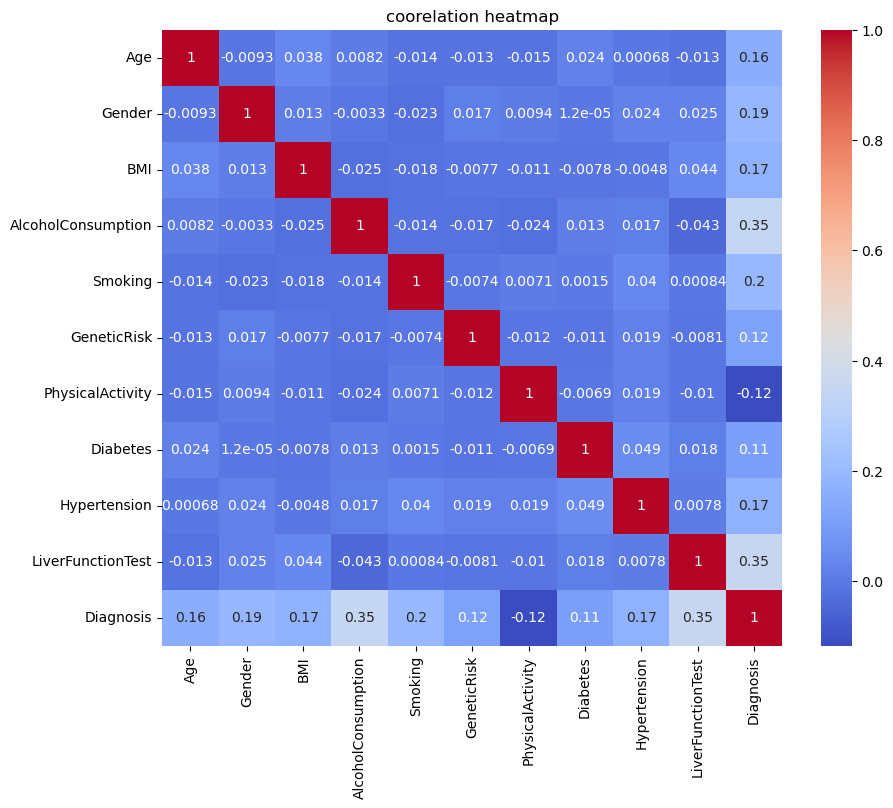

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize = (10,8))
sns.heatmap(df.corr(),annot = True,cmap ="coolwarm")
plt.title("coorelation heatmap")
plt.show()

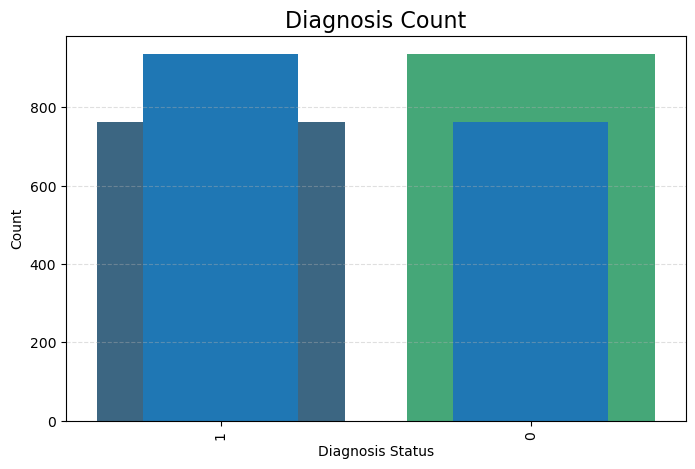

In [10]:
plt.figure(figsize = (8,5))
sns.countplot(x= "Diagnosis", data = df, hue = "Diagnosis",palette = "viridis" , legend = False )
df["Diagnosis"].value_counts().plot(kind = "bar")
plt.title("Diagnosis Count",fontsize = 16)
plt.xlabel("Diagnosis Status")
plt.ylabel("Count")
plt.grid (axis = "y" , linestyle = "--",alpha = 0.4)
plt.show()

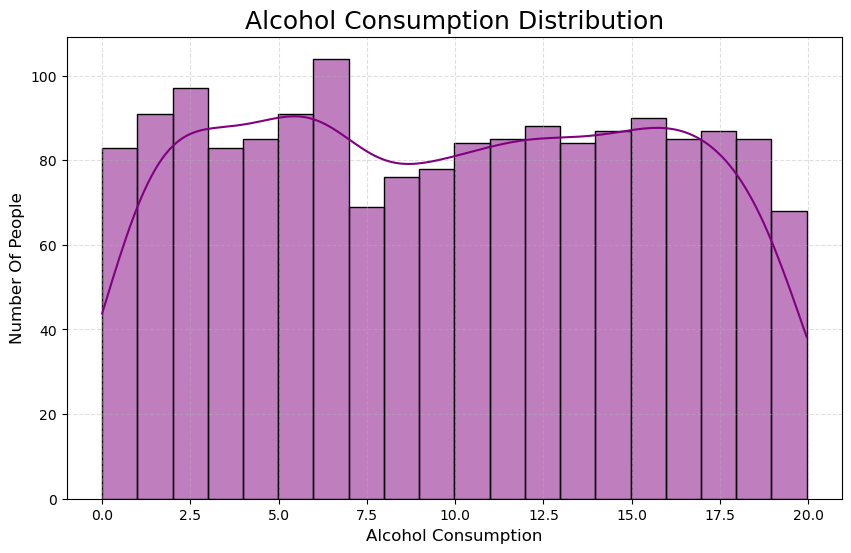

In [11]:
plt.figure(figsize =(10,6))

sns.histplot(df["AlcoholConsumption"],bins = 20,kde = True, color = "purple")
plt.title("Alcohol Consumption Distribution" , fontsize = 18)
plt.xlabel("Alcohol Consumption",fontsize = 12)
plt.ylabel("Number Of People",fontsize = 12)
plt.grid( linestyle = '--', alpha = 0.4)
plt.show()




In [12]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
print(y_pred[:15])


[1 1 1 0 1 1 1 1 1 1 1 1 1 1 0]


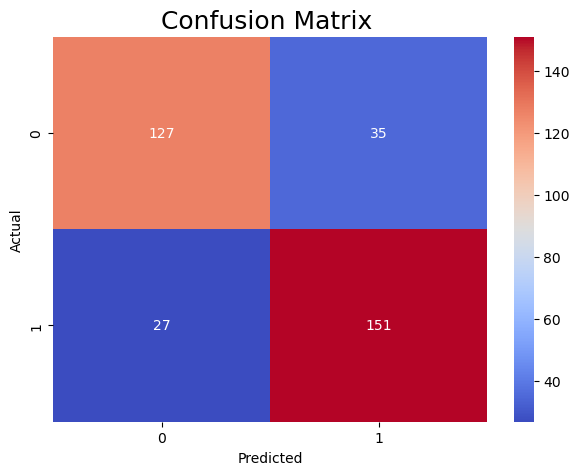

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns 
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test,y_pred)
plt.figure(figsize = (7,5))
sns.heatmap(cm, annot = True,fmt = "d", cmap = 'coolwarm')
plt.title("Confusion Matrix " , fontsize = 18)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [14]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test , y_pred)
print("accuracy =", accuracy)
print("accuracy =", accuracy*100, "%")

accuracy = 0.8176470588235294
accuracy = 81.76470588235294 %


In [15]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))
      

              precision    recall  f1-score   support

           0       0.82      0.78      0.80       162
           1       0.81      0.85      0.83       178

    accuracy                           0.82       340
   macro avg       0.82      0.82      0.82       340
weighted avg       0.82      0.82      0.82       340



In [16]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier( n_estimators = 100, random_state = 42)
rf.fit(X_train,y_train)
rf_pred = rf.predict(X_test)
from sklearn.metrics import accuracy_score
rf_accuracy = accuracy_score(y_test,rf_pred)
print("RANDOM FOREST ACCURACY :" ,rf_accuracy*100)

RANDOM FOREST ACCURACY : 90.29411764705883


In [17]:
importance = rf.feature_importances_
feature_importance = pd.DataFrame({"Feature":X.columns,"Importance": importance})
feature_importance = feature_importance.sort_values(by = "Importance", ascending = False)
print("FEATURE IMPORTANCE")
print(feature_importance)

FEATURE IMPORTANCE
              Feature  Importance
3  AlcoholConsumption    0.250244
9   LiverFunctionTest    0.236504
2                 BMI    0.117660
0                 Age    0.110756
6    PhysicalActivity    0.103177
5         GeneticRisk    0.045610
1              Gender    0.043063
4             Smoking    0.041516
8        Hypertension    0.033062
7            Diabetes    0.018408


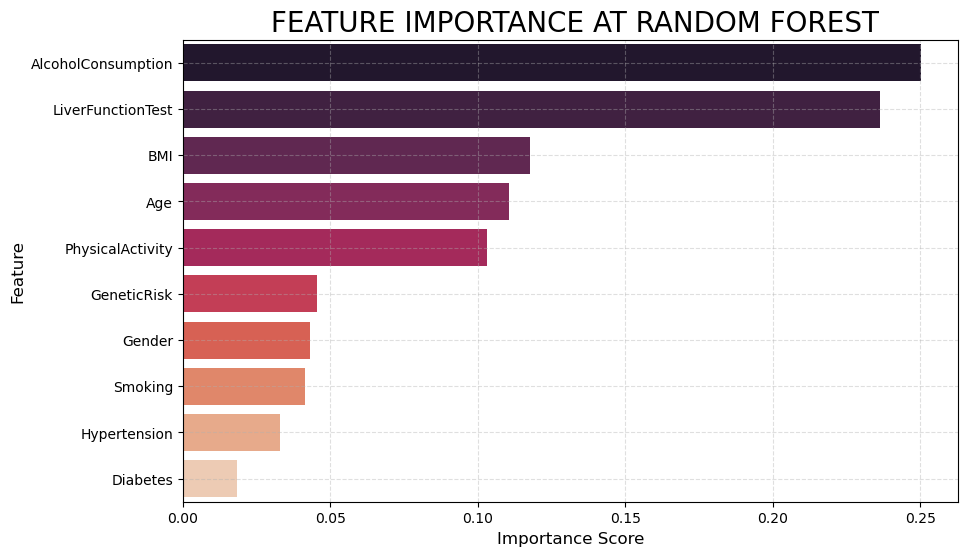

In [18]:
plt.figure(figsize = (10,6))
sns.barplot(x = "Importance",y = "Feature",hue = "Feature", data = feature_importance , palette = "rocket" ,legend = False)
plt.title(" FEATURE IMPORTANCE AT RANDOM FOREST", fontsize = 20)
plt.xlabel("Importance Score" , fontsize = 12)
plt.ylabel("Feature", fontsize = 12)
plt.grid( linestyle = '--', alpha = 0.4)
plt.show()




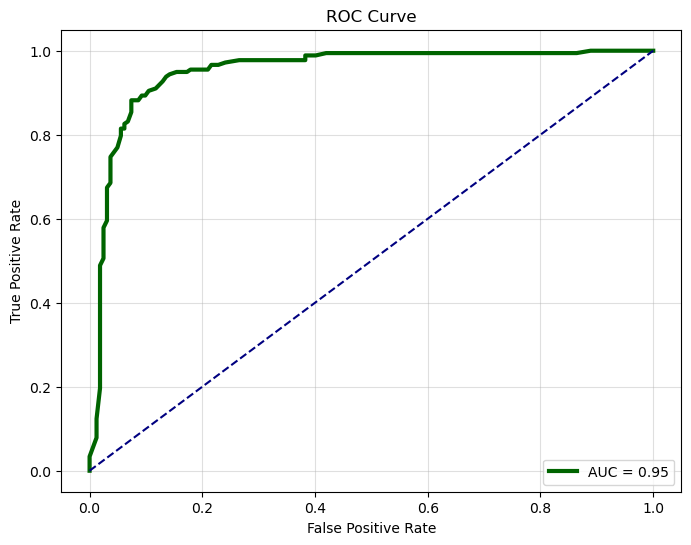

In [19]:
from sklearn.metrics import roc_curve, auc

y_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, threshold = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr,
         color="darkgreen",
         linewidth=3,
         label="AUC = %0.2f" % roc_auc)

plt.plot([0,1],[0,1],
         linestyle="--",
         color="navy")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")

plt.grid(alpha=0.4)

plt.show()

In [19]:
#lets prdict
new_data = pd.DataFrame([[9,1,270,90,0,1,5,0,0,65]], columns = X.columns)
new_data_scaled = scaler.transform(new_data)
prediction = rf.predict(new_data_scaled)
if prediction[0] == 1:
  print("prediction: liver disease")
else:
  print("predicton:No liver disease")

prediction: liver disease


In [22]:
import pickle
with open('model.pkl','wb') as file:
    pickle.dump(rf, file)